# Demonstrating pavement plots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import pavement

### Showing four data sets, with comparison to box plots

In [2]:
# Generate example data inspired by
# https://vita.had.co.nz/papers/boxplots.pdf (Figure 4)

rng = np.random.default_rng(42)
N = 1000

n  = rng.standard_normal(N)                              # standard normal
s  = rng.lognormal(0, 0.5, N) - 1.0                      # right-skewed (shifted lognormal)
k  = rng.standard_t(df=4, size=N) * 0.5                  # leptokurtic (heavy-tailed t)
mm = np.concatenate([rng.normal(-1, 0.35, N // 2),       # bimodal mixture
                     rng.normal( 1, 0.35, N // 2)])
rng.shuffle(mm)

labels = ['bimodal', 'leptokurtic', 'right-skewed', 'normal']

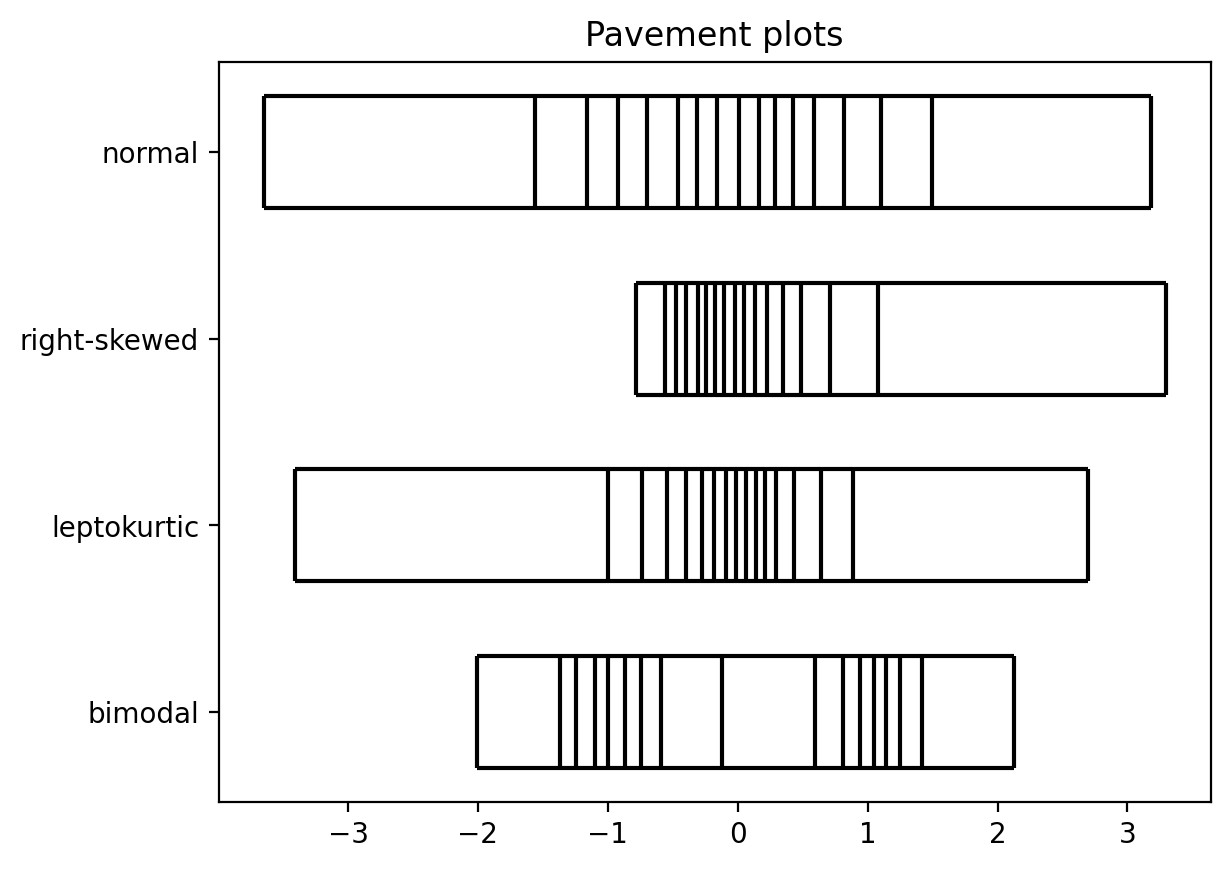

In [3]:
bins=16
pavement.plot(sorted(n), bins=bins, ypos=3)
pavement.plot(sorted(s), bins=bins, ypos=2)
pavement.plot(sorted(k), bins=bins, ypos=1)
pavement.plot(sorted(mm), bins=bins, ypos=0)
plt.gca().set_yticks([0, 1, 2, 3], labels)
plt.title('Pavement plots')
plt.show()

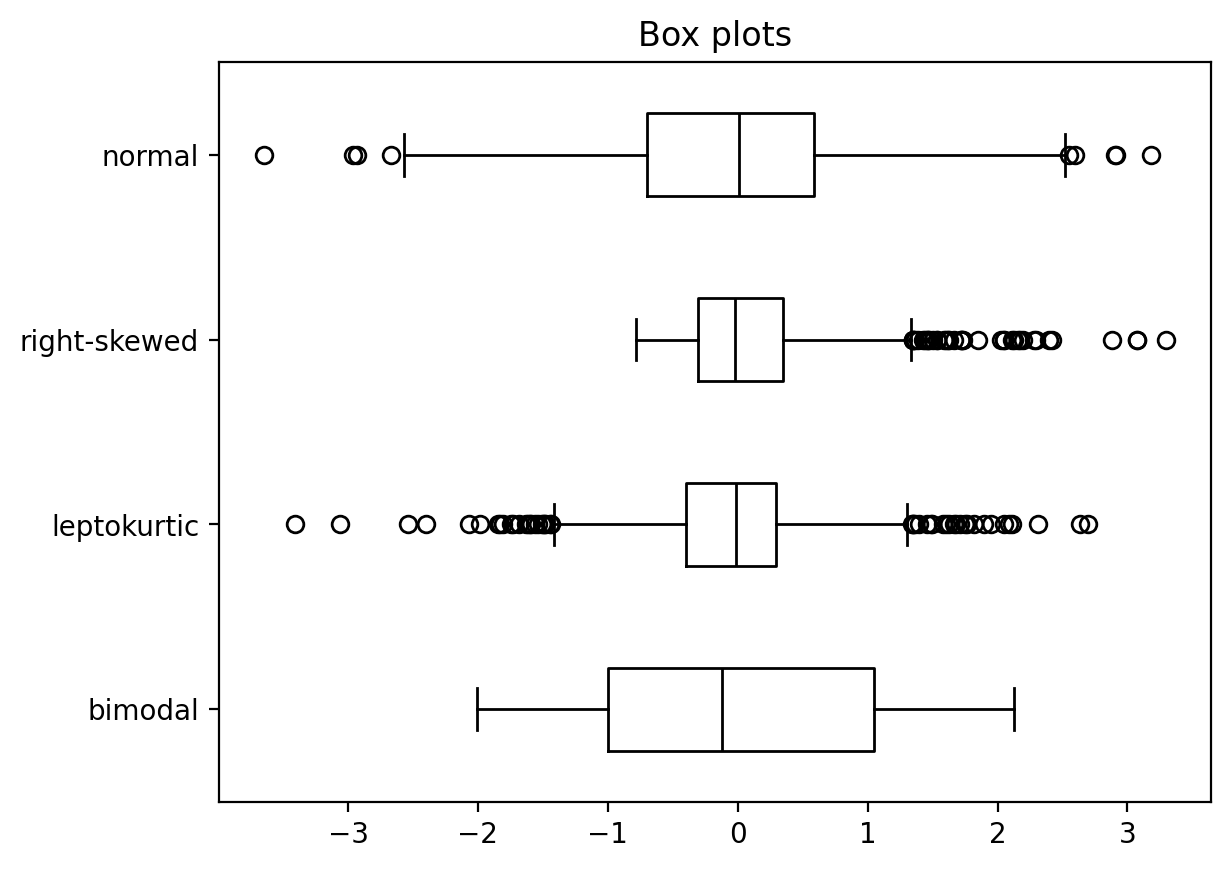

In [4]:
plt.boxplot([mm, k, s, n], tick_labels=labels,
            orientation='horizontal', medianprops={'color': 'black'})
plt.title('Box plots')
plt.show()

### Showing eight subsets

In [5]:
# The classic `singer` dataset as in R's `lattice` package
singers = pd.read_csv('singers.csv')

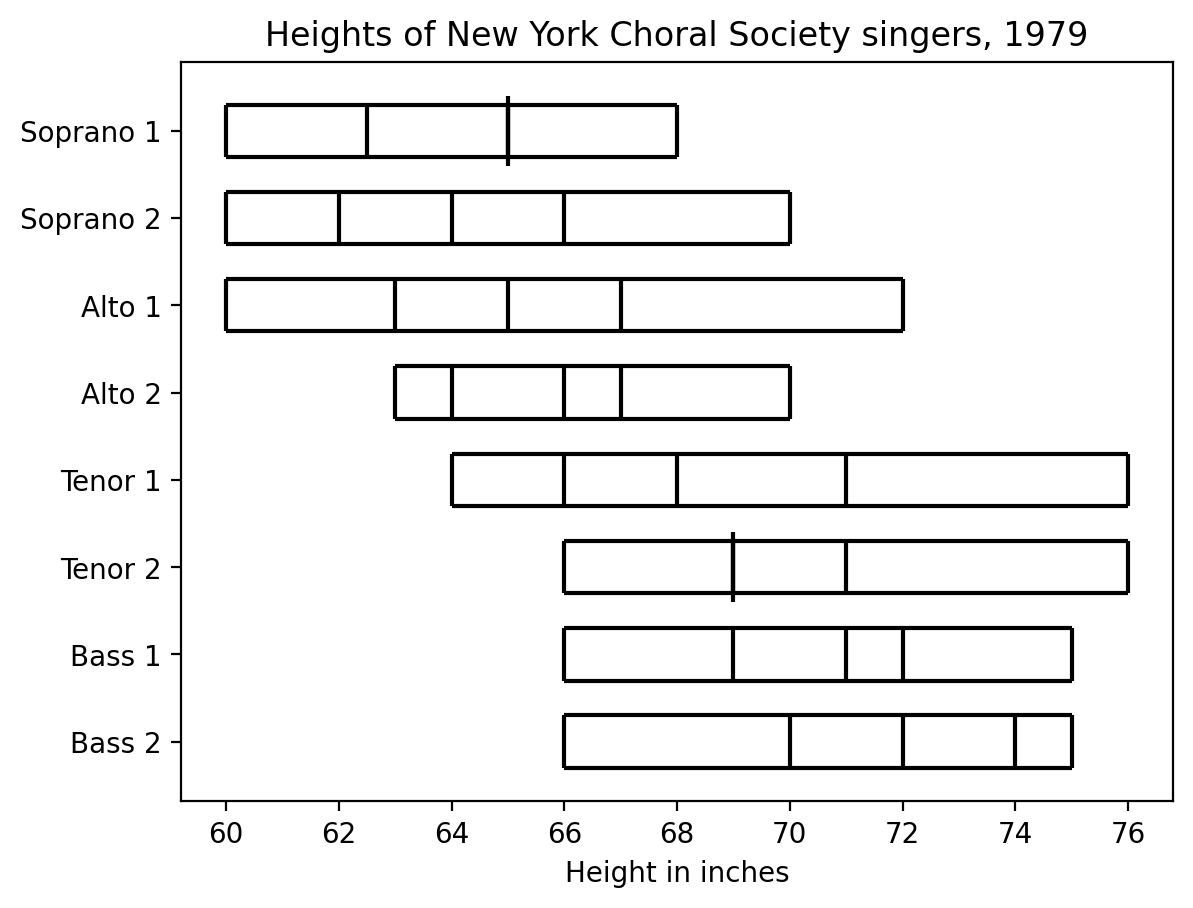

In [6]:
labels = ['Soprano 1', 'Soprano 2', 'Alto 1', 'Alto 2', 'Tenor 1', 'Tenor 2', 'Bass 1', 'Bass 2']
pavement.multi(singers.height, singers.part, labels=labels)
plt.xlabel('Height in inches')
plt.title('Heights of New York Choral Society singers, 1979')
plt.show()

### Showing US income data

In [7]:
# This is a subset of an American Community Survey file,
# https://www2.census.gov/programs-surveys/acs/data/pums/2024/1-Year/csv_pus.zip
# The columns have been renamed
# from PWGTP, PINCP, and AGEP,
# to sample_weight, dollars, and age.
# ADJINC for all of these was 1015250,
# but nominal dollars are used instead of adjusting.
incomes = pd.read_csv('incomes.csv')

In [8]:
incomes['decade'] = (incomes.age // 10).astype('str') + '0s'

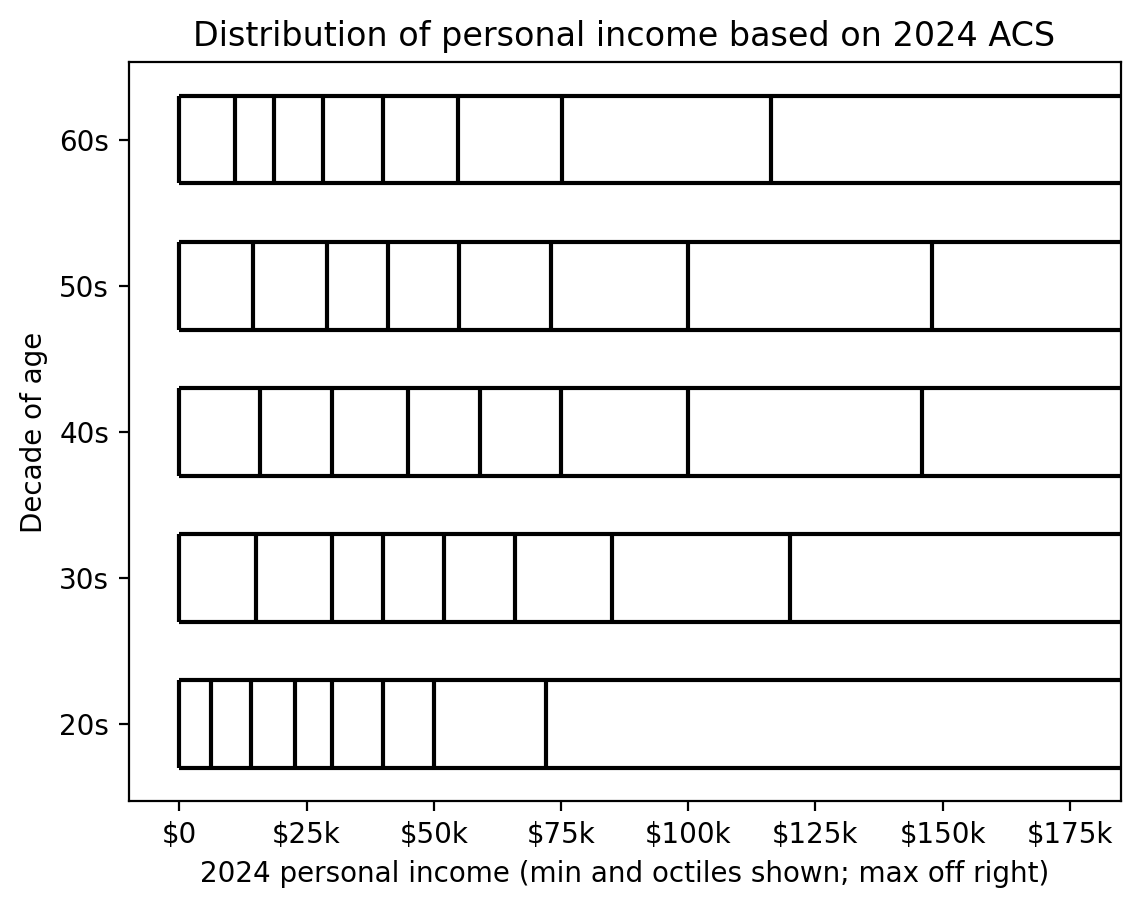

In [9]:
pavement.multi(incomes.dollars, incomes.decade,
               labels=['60s', '50s', '40s', '30s', '20s'],
               weights=incomes.sample_weight, bins=8)
plt.xlim(-10_000, 185_000)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k' if x != 0 else '$0'))
plt.xlabel('2024 personal income (min and octiles shown; max off right)')
plt.ylabel('Decade of age')
plt.title('Distribution of personal income based on 2024 ACS')
plt.show()

In [10]:
ages = list(range(20, 70))
bins = 8
levels = list(x/bins for x in range(bins + 1))
quantiles = []
for age in ages:
    data, weights = pavement.sort(incomes.dollars[incomes.age == age],
                                  incomes.sample_weight[incomes.age == age])
    quantiles.append(pavement.quantiles(data, levels, weights))

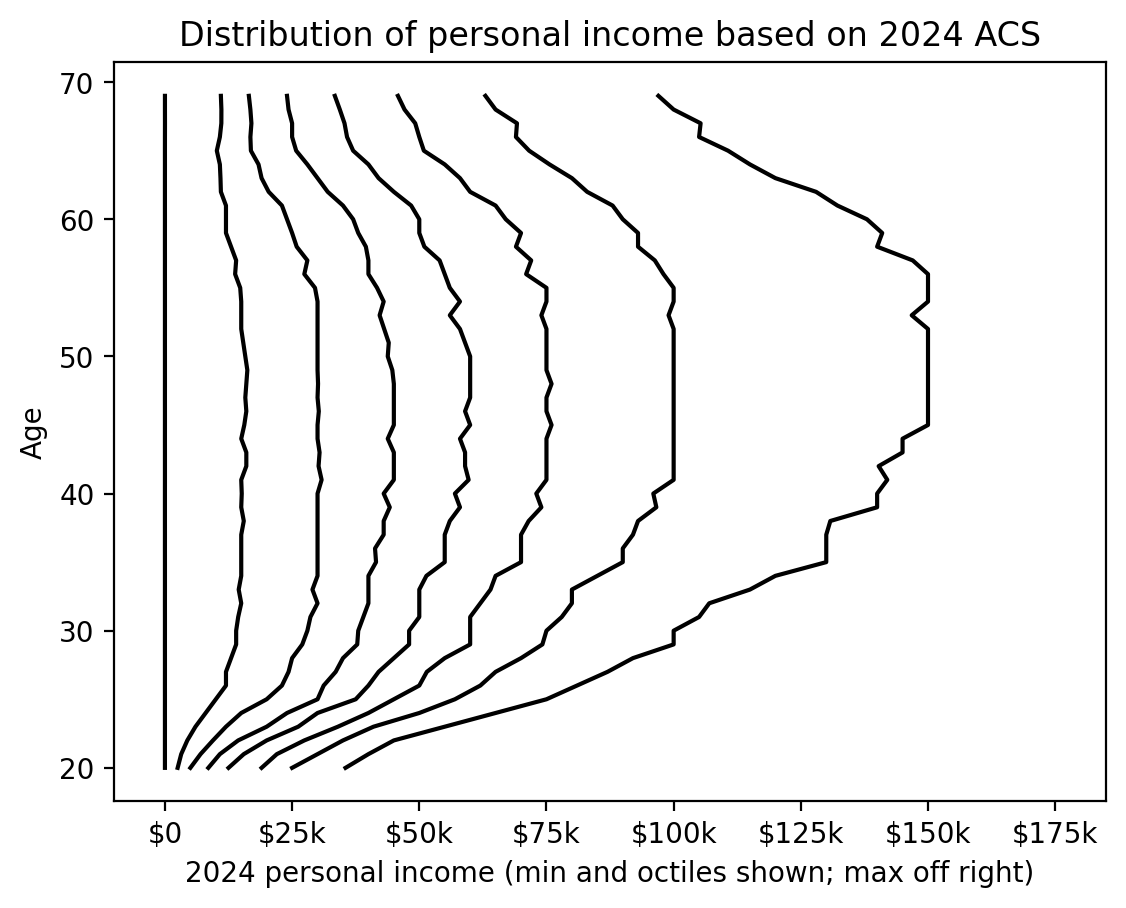

In [11]:
for index, series in enumerate(np.stack(quantiles).T):
    plt.plot(series, ages, color='black')
plt.xlim(-10_000, 185_000)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k' if x != 0 else '$0'))
plt.xlabel('2024 personal income (min and octiles shown; max off right)')
plt.ylabel('Age')
plt.title('Distribution of personal income based on 2024 ACS')
plt.show()